#02 原型测试

该笔记本验证了离线最小训练原型。它旨在快速功能验证，而不是最终性能报告。

## 笔记本约定

这里使用的规则：
- 笔记本用于探索和验证，
- 可重用逻辑应移至“src/”，
- 为了长期可维护性，需要编号命名。

## 1) 环境设置

此部分初始化路径、随机性控制和输出目录。管理导入顺序以避免“src”包阴影问题。

In [1]:
from __future__ import annotations

import copy
import math
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DCD_ROOT = ROOT / 'DCD_MUSIC'
# Keep project root first; append DCD_MUSIC path for package resolution.
if str(DCD_ROOT) not in sys.path:
    sys.path.append(str(DCD_ROOT))

FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('root:', ROOT)
print('device:', device)
print('dcd_exists:', DCD_ROOT.exists(), 'non_empty:', DCD_ROOT.exists() and any(DCD_ROOT.iterdir()))

root: D:\LiLei\Python_projects\SubspaceNet_Update
device: cpu
dcd_exists: True non_empty: True


## 2) 导入和实用函数

本节定义：
- 紧凑的配置覆盖快速运行，
- 结构化状态记录，
- 统一的表格报告助手。

In [2]:
from config.loader import load_config
from config.factory import create_system_model, create_model
from src.data_module.trajectory import TrajectoryDataHandler
from src.data_module.lit_datamodule import DOADataModule
from src.eval_module.metrics.rmspe_loss import RMSPELoss


@dataclass
class StepResult:
    name: str
    ok: bool
    message: str
    elapsed_s: float


def dcd_available() -> bool:
    return DCD_ROOT.exists() and any(DCD_ROOT.iterdir())


def build_fast_config(
    samples_size: int = 48,
    trajectory_length: int = 12,
    batch_size: int = 8,
    epochs: int = 2,
    trajectory_type: str = 'random_walk',
    random_walk_std_dev: float = 2.0,
):
    cfg = load_config(str(ROOT / 'configs' / 'default_config.yaml'))
    cfg.dataset.samples_size = samples_size
    cfg.dataset.create_data = True
    cfg.dataset.save_dataset = False

    cfg.trajectory.enabled = True
    cfg.trajectory.trajectory_length = trajectory_length
    cfg.trajectory.trajectory_type = trajectory_type
    cfg.trajectory.random_walk_std_dev = float(random_walk_std_dev)
    cfg.trajectory.save_trajectory = False

    cfg.training.batch_size = batch_size
    cfg.training.epochs = epochs
    cfg.training.learning_rate = 1e-3

    # Keep source count fixed for stable RMSPE dimensions.
    cfg.system_model.M = 3
    return cfg


def format_status_table(rows: List[StepResult]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            'step': r.name,
            'ok': r.ok,
            'elapsed_s': round(r.elapsed_s, 4),
            'message': r.message,
        }
        for r in rows
    ])

Running on device:  cpu


## 3) 冒烟测试 A：TrajectoryDataHandler

验证目标：
- 数据集生成成功，
- 返回的结构和形状是连贯的，
- 核心轨迹管道中没有立即运行时异常。

,step,ok,elapsed_s,message
0,TrajectoryDataHandler smoke test,True,0.2136,"OK: len=48, x0=(12, 8, 200), m_len=12, y_len=12"


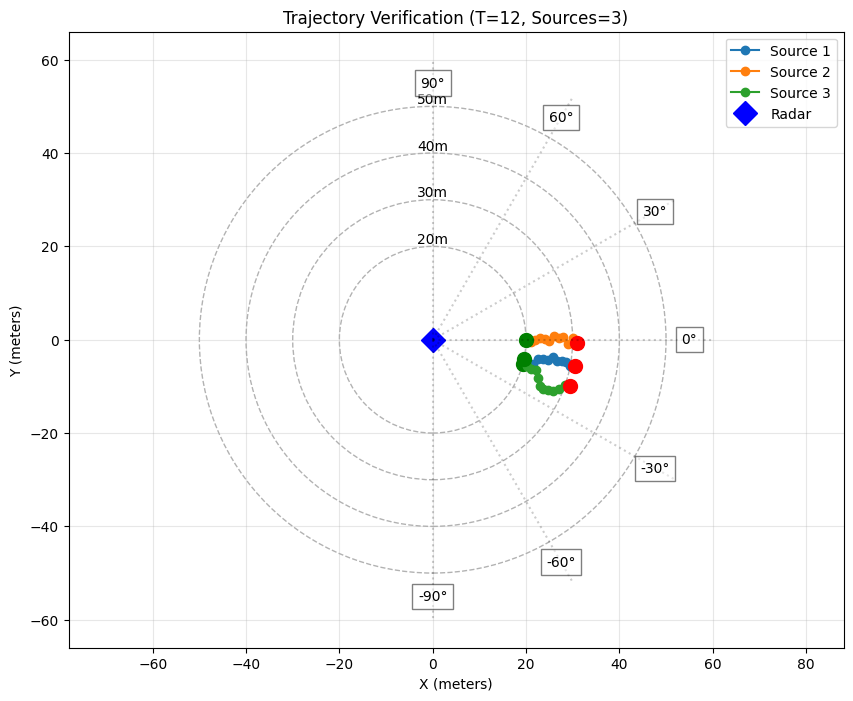

In [3]:
def smoke_test_trajectory_handler(cfg) -> StepResult:
    start = time.perf_counter()
    name = 'TrajectoryDataHandler smoke test'

    if not dcd_available():
        return StepResult(name, False, 'SKIPPED: DCD_MUSIC submodule is not initialized', time.perf_counter() - start)

    try:
        system_model = create_system_model(cfg)
        handler = TrajectoryDataHandler(system_model_params=system_model.params, config=cfg)
        ds, _ = handler.create_dataset(
            samples_size=cfg.dataset.samples_size,
            trajectory_length=cfg.trajectory.trajectory_length,
            trajectory_type=cfg.trajectory.trajectory_type,
            save_dataset=False,
        )

        x0, m0, y0 = ds[0]
        msg = f'OK: len={len(ds)}, x0={tuple(x0.shape)}, m_len={len(m0)}, y_len={len(y0)}'
        return StepResult(name, True, msg, time.perf_counter() - start)
    except Exception as exc:
        return StepResult(name, False, f'FAIL: {type(exc).__name__}: {exc}', time.perf_counter() - start)


cfg_base = build_fast_config()
res_handler = smoke_test_trajectory_handler(cfg_base)
format_status_table([res_handler])

## 4) 冒烟测试 B：DOADataModule

验证目标：
- 分割创作作品，
- 数据加载器返回有效批次，
- 张量和标签尺寸对齐。

,step,ok,elapsed_s,message
0,DOADataModule smoke test,True,0.196,"OK: train=28, val=9, test=11, batch_x=(8, 12, ..."


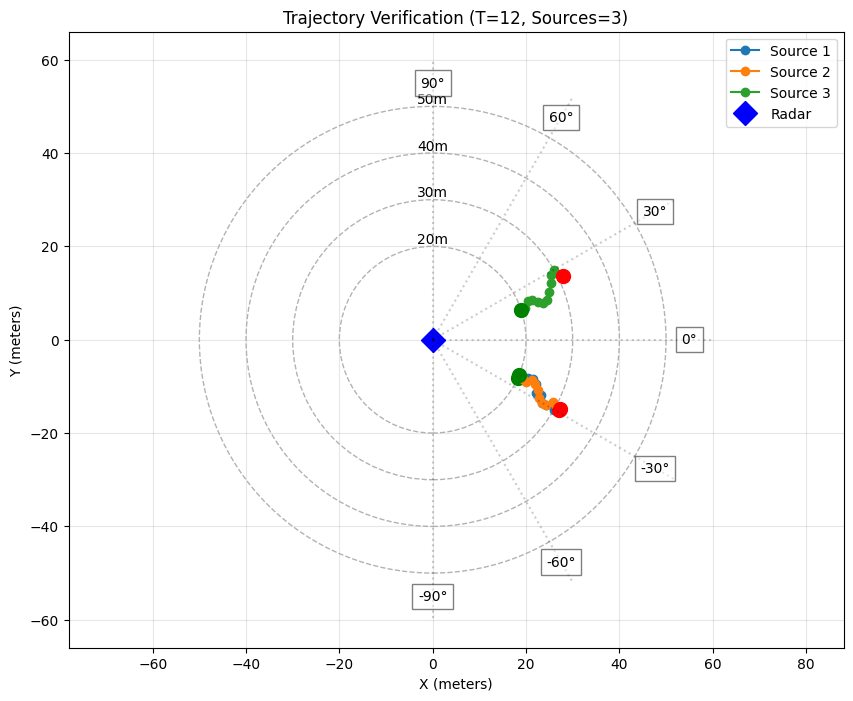

In [4]:
def smoke_test_datamodule(cfg) -> StepResult:
    start = time.perf_counter()
    name = 'DOADataModule smoke test'

    if not dcd_available():
        return StepResult(name, False, 'SKIPPED: DCD_MUSIC submodule is not initialized', time.perf_counter() - start)

    try:
        system_model = create_system_model(cfg)
        dm = DOADataModule(cfg, system_model)
        dm.setup('fit')

        train_dl = dm.train_dataloader()
        batch = next(iter(train_dl))
        x, m, y = batch
        msg = (
            f'OK: train={len(dm.train_dataset)}, val={len(dm.val_dataset)}, test={len(dm.test_dataset)}, '
            f'batch_x={tuple(x.shape)}, batch_m={tuple(m.shape)}, batch_y={tuple(y.shape)}'
        )
        return StepResult(name, True, msg, time.perf_counter() - start)
    except Exception as exc:
        return StepResult(name, False, f'FAIL: {type(exc).__name__}: {exc}', time.perf_counter() - start)


res_dm = smoke_test_datamodule(cfg_base)
format_status_table([res_dm])

## 5) 冒烟测试 C：模型转发

验证目标：
- 模型工厂实例化工作，
- 至少一个前向签名成功，
- 输出格式可用于损失计算。

SubspaceNet does not accept kwargs ['batch_norm', 'norm_layer', 'regularization', 'train_loss_type', 'variant']; dropping them for compatibility


,step,ok,elapsed_s,message
0,Model forward smoke test,True,0.2331,"OK: output=(8, 3), (8,), ()"


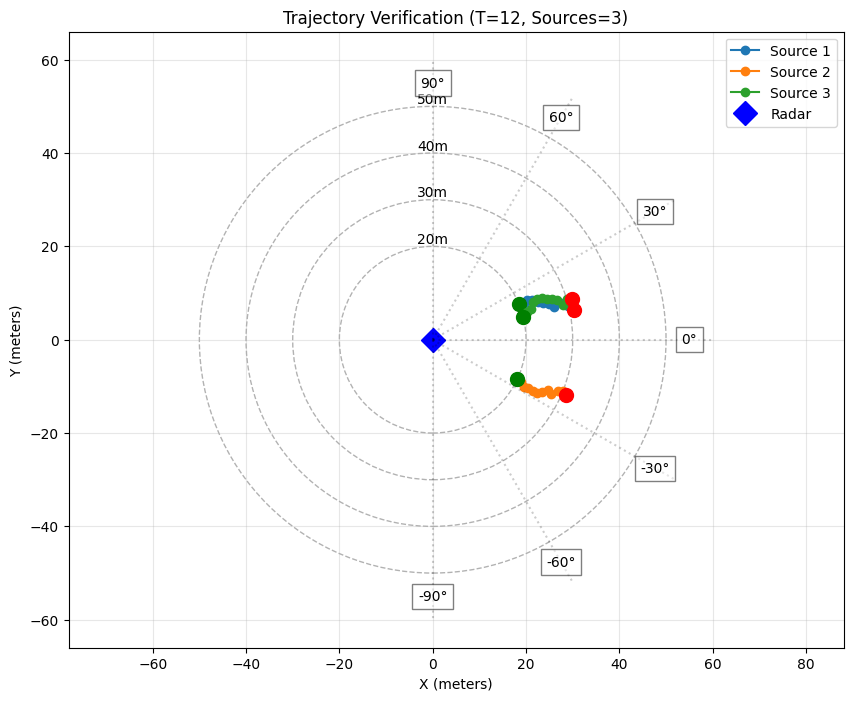

In [5]:
def smoke_test_model_forward(cfg) -> StepResult:
    start = time.perf_counter()
    name = 'Model forward smoke test'

    if not dcd_available():
        return StepResult(name, False, 'SKIPPED: DCD_MUSIC submodule is not initialized', time.perf_counter() - start)

    try:
        system_model = create_system_model(cfg)
        dm = DOADataModule(cfg, system_model)
        dm.setup('fit')
        x, m, _ = next(iter(dm.train_dataloader()))

        model = create_model(cfg, system_model)
        model = model.to(device)
        x = x.to(device)
        m = m.to(device)

        out = None
        last_err = None
        for call in (
            lambda: model(x, m),
            lambda: model(x),
            lambda: model(x[:, -1], m[:, -1]),
            lambda: model(x[:, -1]),
        ):
            try:
                out = call()
                break
            except Exception as exc:
                last_err = exc

        if out is None:
            raise RuntimeError(f'All forward signatures failed; last error: {last_err}')

        if isinstance(out, (tuple, list)):
            out_desc = ', '.join(str(tuple(t.shape)) for t in out if hasattr(t, 'shape'))
        elif hasattr(out, 'shape'):
            out_desc = str(tuple(out.shape))
        else:
            out_desc = f'type={type(out).__name__}'

        return StepResult(name, True, f'OK: output={out_desc}', time.perf_counter() - start)
    except Exception as exc:
        return StepResult(name, False, f'FAIL: {type(exc).__name__}: {exc}', time.perf_counter() - start)


res_fwd = smoke_test_model_forward(cfg_base)
format_status_table([res_fwd])

## 6) 最小离线训练原型

一个微型模型经过两个 epoch 的训练，以验证优化、度量计算和运行时日志记录是否能够端到端运行。

,status,message,loss,rmspe_deg,runtime_s
0,OK,prototype training finished,0.213309,12.221733,0.216124


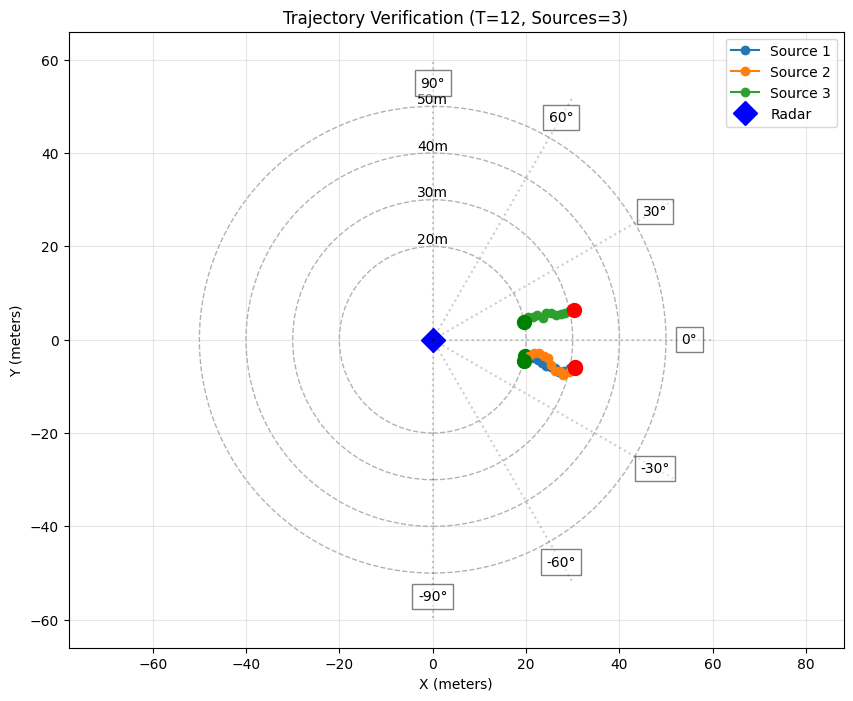

In [6]:
class TinyAngleRegressor(nn.Module):
    def __init__(self, n_sensors: int, n_sources: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * n_sensors, 64),
            nn.ReLU(),
            nn.Linear(64, n_sources),
        )

    def forward(self, x_last_step: torch.Tensor) -> torch.Tensor:
        # x_last_step: [B, N, T] complex
        feat_real = x_last_step.real.mean(dim=-1)
        feat_imag = x_last_step.imag.mean(dim=-1)
        feat = torch.cat([feat_real, feat_imag], dim=-1)
        return self.net(feat)


def run_tiny_prototype(cfg) -> Dict[str, Any]:
    t0 = time.perf_counter()

    if not dcd_available():
        return {
            'status': 'SKIPPED',
            'message': 'DCD_MUSIC submodule is not initialized',
            'loss': np.nan,
            'rmspe_deg': np.nan,
            'runtime_s': time.perf_counter() - t0,
        }

    system_model = create_system_model(cfg)
    dm = DOADataModule(cfg, system_model)
    dm.setup('fit')

    train_dl = dm.train_dataloader()
    n_sensors = int(cfg.system_model.N)
    n_sources = int(cfg.system_model.M)

    model = TinyAngleRegressor(n_sensors=n_sensors, n_sources=n_sources).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.training.learning_rate)
    criterion = RMSPELoss().to(device)

    last_epoch_loss = float('nan')
    last_epoch_rmspe_deg = float('nan')

    for _ in range(cfg.training.epochs):
        model.train()
        epoch_losses = []
        epoch_rmspe = []

        for x, _, y in train_dl:
            x = x.to(device)
            y = y.to(device)

            # Use final step in trajectory for quick prototype supervision.
            x_last = x[:, -1]           # [B, N, T]
            y_last = y[:, -1, :n_sources]  # [B, M]

            pred = model(x_last)
            loss = criterion(pred, y_last) / max(1, x_last.size(0))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(float(loss.detach().cpu().item()))
            epoch_rmspe.append(float(loss.detach().cpu().item() * 180.0 / math.pi))

        last_epoch_loss = float(np.mean(epoch_losses)) if epoch_losses else float('nan')
        last_epoch_rmspe_deg = float(np.mean(epoch_rmspe)) if epoch_rmspe else float('nan')

    return {
        'status': 'OK',
        'message': 'prototype training finished',
        'loss': last_epoch_loss,
        'rmspe_deg': last_epoch_rmspe_deg,
        'runtime_s': time.perf_counter() - t0,
    }


proto_result = run_tiny_prototype(cfg_base)
pd.DataFrame([proto_result])

## 7) 快速比较实验

本节通过更改“trajectory_type”和“random_walk_std_dev”来比较几种轨迹配置，然后记录损失/RMSPE/运行时间。

,trajectory_type,random_walk_std_dev,status,loss,rmspe_deg,runtime_s,message
0,random_walk,1.0,OK,0.203176,11.641130,0.215646,prototype training finished
1,random_walk,5.0,OK,0.242494,13.893886,0.275511,prototype training finished
2,static,1.0,OK,0.224740,12.876663,0.320410,prototype training finished


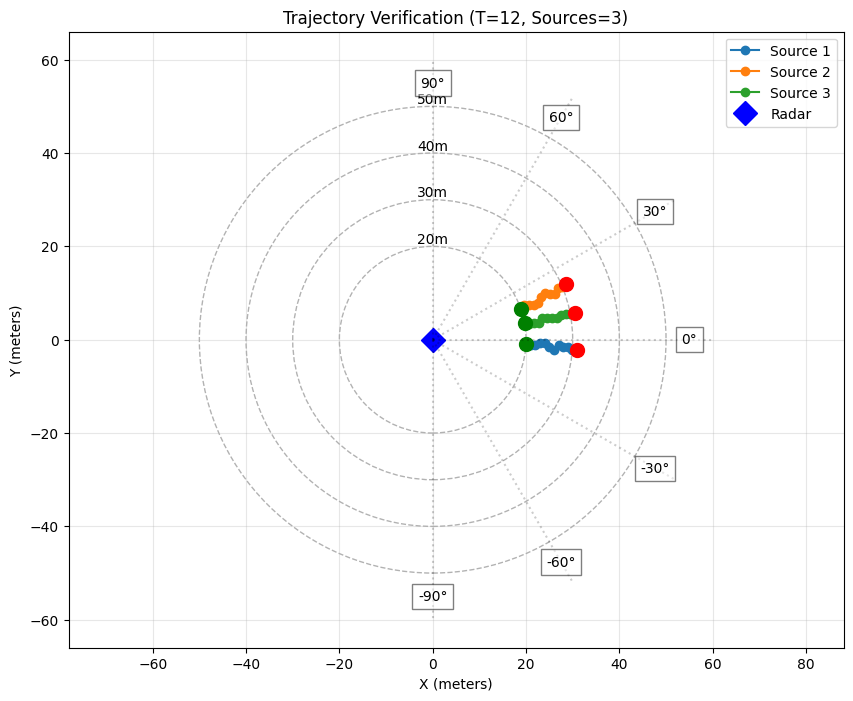

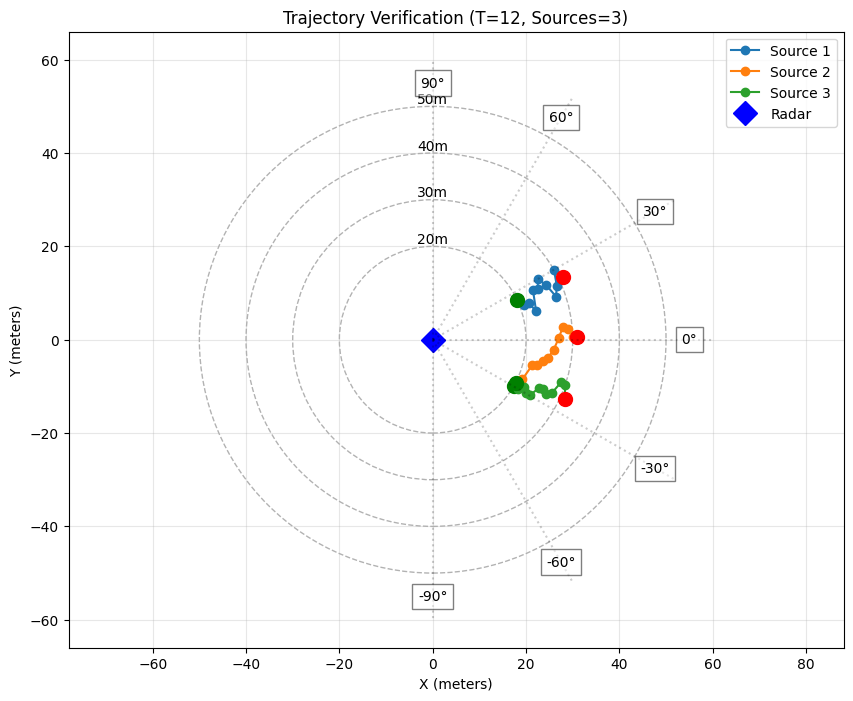

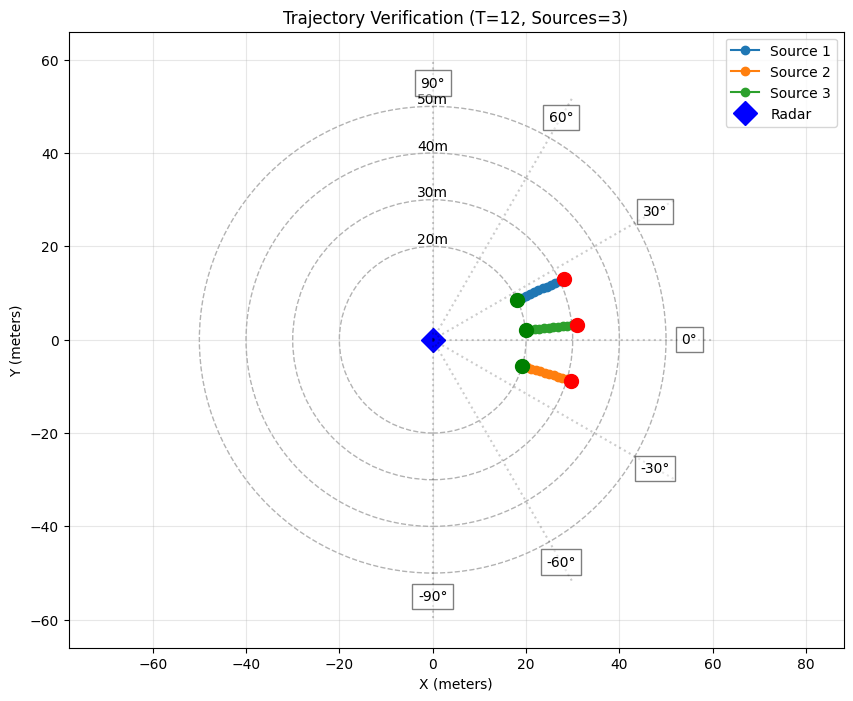

In [7]:
settings = [
    {'trajectory_type': 'random_walk', 'random_walk_std_dev': 1.0},
    {'trajectory_type': 'random_walk', 'random_walk_std_dev': 5.0},
    {'trajectory_type': 'static', 'random_walk_std_dev': 1.0},
]

rows = []
for s in settings:
    cfg = build_fast_config(
        samples_size=48,
        trajectory_length=12,
        batch_size=8,
        epochs=2,
        trajectory_type=s['trajectory_type'],
        random_walk_std_dev=s['random_walk_std_dev'],
    )
    out = run_tiny_prototype(cfg)
    rows.append({
        'trajectory_type': s['trajectory_type'],
        'random_walk_std_dev': s['random_walk_std_dev'],
        'status': out['status'],
        'loss': out['loss'],
        'rmspe_deg': out['rmspe_deg'],
        'runtime_s': out['runtime_s'],
        'message': out['message'],
    })

comparison_df = pd.DataFrame(rows)
comparison_df

### 7.1 图 A：RMSPE 的单杠

该图比较了不同设置的错误级别。水平布局是首选，因为设置标签相对较长。

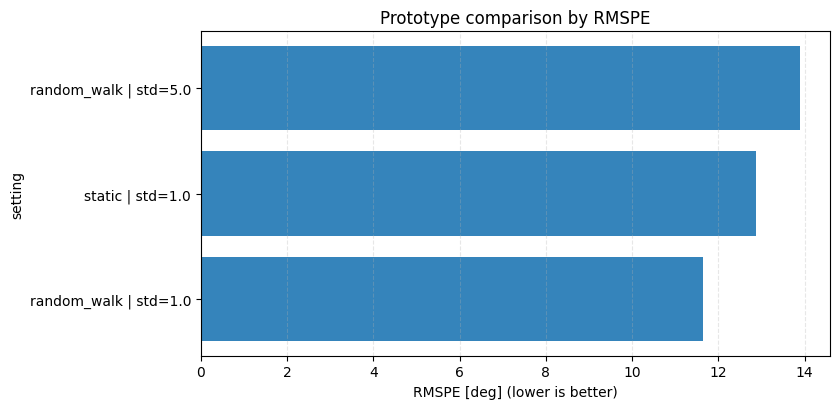

In [8]:
plot_df = comparison_df.copy()
plot_df = plot_df[plot_df['status'] == 'OK'].copy()
plot_df['setting'] = plot_df.apply(
    lambda r: f"{r['trajectory_type']} | std={r['random_walk_std_dev']}", axis=1
)
plot_df = plot_df.sort_values('rmspe_deg', ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(plot_df['setting'], plot_df['rmspe_deg'], color='#1f77b4', alpha=0.9)
ax.set_xlabel('RMSPE [deg] (lower is better)')
ax.set_ylabel('setting')
ax.set_title('Prototype comparison by RMSPE')
ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'prototype_rmspe_barh.png', dpi=180)
plt.show()

### 7.2 图 B：帕累托前沿（RMSPE 与运行时）

该图突出显示了两个目标权衡下的非支配设置：较低的错误和较低的运行时间。

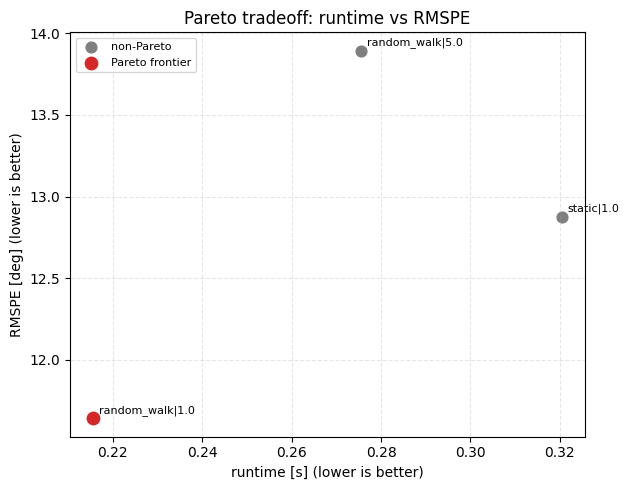

In [9]:
pareto_df = comparison_df.copy()
pareto_df = pareto_df[pareto_df['status'] == 'OK'].copy()
pareto_df['setting'] = pareto_df.apply(
    lambda r: f"{r['trajectory_type']}|{r['random_walk_std_dev']}", axis=1
)

X = pareto_df['runtime_s'].to_numpy(dtype=float)
Y = pareto_df['rmspe_deg'].to_numpy(dtype=float)

is_pareto = np.ones(len(pareto_df), dtype=bool)
for i in range(len(pareto_df)):
    for j in range(len(pareto_df)):
        if i == j:
            continue
        if (X[j] <= X[i] and Y[j] <= Y[i]) and (X[j] < X[i] or Y[j] < Y[i]):
            is_pareto[i] = False
            break

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.scatter(X[~is_pareto], Y[~is_pareto], color='#7f7f7f', s=60, label='non-Pareto')
ax.scatter(X[is_pareto], Y[is_pareto], color='#d62728', s=80, label='Pareto frontier')

for _, r in pareto_df.iterrows():
    ax.annotate(r['setting'], (r['runtime_s'], r['rmspe_deg']), textcoords='offset points', xytext=(4,4), fontsize=8)

# Draw frontier line in ascending runtime order
frontier = pareto_df[is_pareto].sort_values('runtime_s')
if len(frontier) >= 2:
    ax.plot(frontier['runtime_s'], frontier['rmspe_deg'], color='#d62728', linewidth=1.5, alpha=0.8)

ax.set_xlabel('runtime [s] (lower is better)')
ax.set_ylabel('RMSPE [deg] (lower is better)')
ax.set_title('Pareto tradeoff: runtime vs RMSPE')
ax.grid(linestyle='--', alpha=0.3)
ax.legend(loc='best', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'prototype_pareto_runtime_rmspe.png', dpi=180)
plt.show()

## 8) 综合结果表

本部分结合冒烟测试状态和原型指标，为下一阶段集成提供单一质量门。

In [10]:
smoke_df = format_status_table([res_handler, res_dm, res_fwd])
smoke_df

,step,ok,elapsed_s,message
0,TrajectoryDataHandler smoke test,True,0.2136,"OK: len=48, x0=(12, 8, 200), m_len=12, y_len=12"
1,DOADataModule smoke test,True,0.1960,"OK: train=28, val=9, test=11, batch_x=(8, 12, ..."
2,Model forward smoke test,True,0.2331,"OK: output=(8, 3), (8,), ()"


### 推荐的日志列

在运行过程中保持这些字段稳定：
`trajectory_type`、`random_walk_std_dev`、`loss`、`rmspe_deg`、`runtime_s`、`status`。

In [11]:
comparison_df.sort_values(['status', 'loss'], ascending=[True, True])

,trajectory_type,random_walk_std_dev,status,loss,rmspe_deg,runtime_s,message
0,random_walk,1.0,OK,0.203176,11.641130,0.215646,prototype training finished
2,static,1.0,OK,0.224740,12.876663,0.320410,prototype training finished
1,random_walk,5.0,OK,0.242494,13.893886,0.275511,prototype training finished


## 9) 移入正式脚本的项目

候选人：
- 快速配置覆盖实用程序，
- 烟雾测试功能，
- 微小的训练循环，
- 通用结果模式。

## 10) 下一步行动

建议顺序：
1. 将烟雾检查移至测试，
2. 将原型循环迁移到脚本运行器中，
3.通过反复试验扩大超参数网格。